In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from PIL import Image
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import numpy as np
import skimage
import matplotlib.pyplot as plt

In [3]:
resolution = 64


def get_mgrid(sidelen, dim=2):
    '''Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int'''
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

In [9]:
def get_cameraman_tensor(sidelength):
    img = Image.fromarray(skimage.data.camera())        
    img = img.crop((192, 128, 320, 256))  # Crop to 128x128
    transform = Compose([
        Resize(sidelength),
        ToTensor(),
        Normalize(torch.Tensor([0.5]), torch.Tensor([0.5]))
    ])

    img = transform(img)
    return img


def get_chest_ct_tensor(sidelength):
    from medmnist import ChestMNIST
    dataset = ChestMNIST(split="train", download=True, size=64)
    img = Image.fromarray(dataset.imgs[0])
    transform = Compose([
        Resize(sidelength),
        ToTensor(),
        Normalize(torch.Tensor([0.5]), torch.Tensor([0.5]))
    ])

    img = transform(img)
    return img

In [4]:
class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.
    
    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the 
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a 
    # hyperparameter.
    
    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of 
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)
    
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 
                                             1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))
    
    
class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False, 
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, 
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, 
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, 
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)
                
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, 
                                      is_first=False, omega_0=hidden_omega_0))
        
        self.net = nn.Sequential(*self.net)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords        

In [5]:
class ImageFitting(Dataset):
    def __init__(self, sidelength):
        super().__init__()
        img = get_chest_ct_tensor(sidelength)
        self.pixels = img.permute(1, 2, 0).view(-1, 1)
        self.coords = get_mgrid(sidelength, 2)

    def __len__(self):
        return 1

    def __getitem__(self, idx):    
        if idx > 0: raise IndexError
        return self.coords, self.pixels

In [10]:
cameraman = ImageFitting(resolution)
dataloader = DataLoader(cameraman, batch_size=1, pin_memory=True, num_workers=0)

/home/hs2286/miniconda3/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


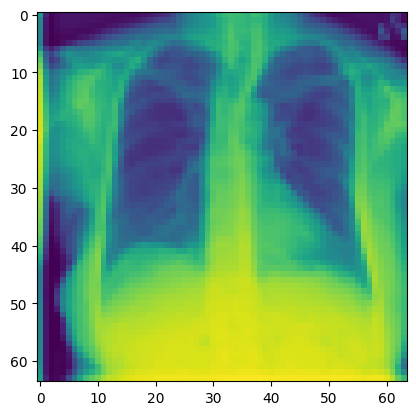

Step 0, Total loss 0.275426


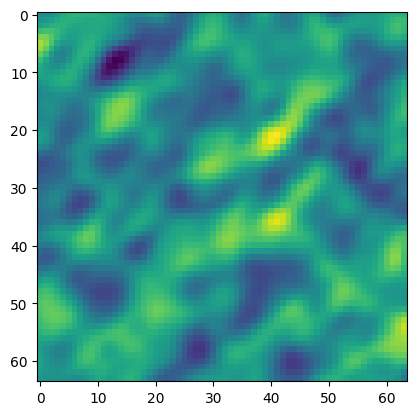

Step 100, Total loss 0.008922


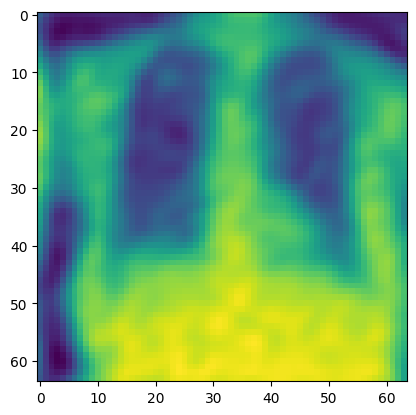

Step 200, Total loss 0.005012


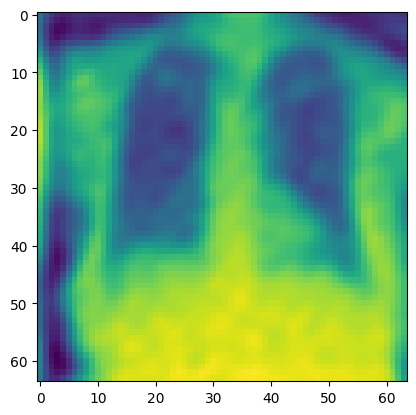

Step 300, Total loss 0.003465


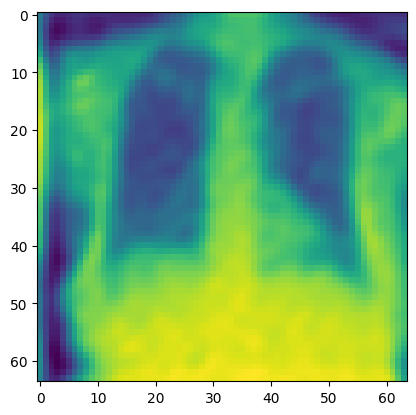

Step 400, Total loss 0.002741


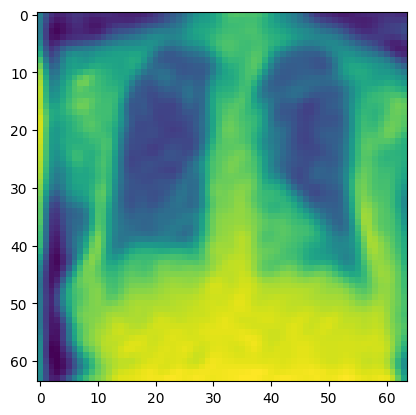

Step 500, Total loss 0.002318


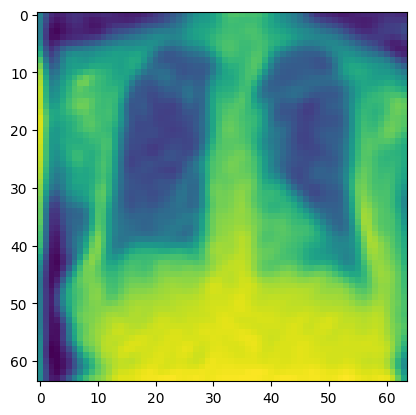

Step 600, Total loss 0.002034


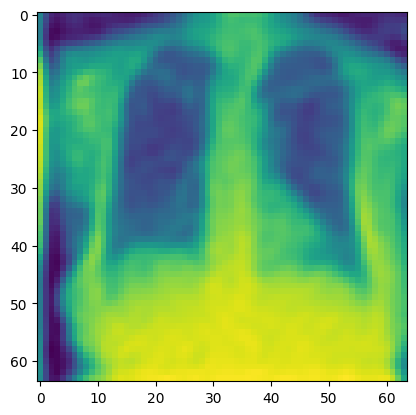

Step 700, Total loss 0.001824


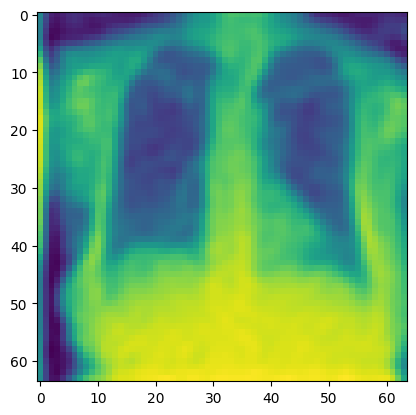

Step 800, Total loss 0.001661


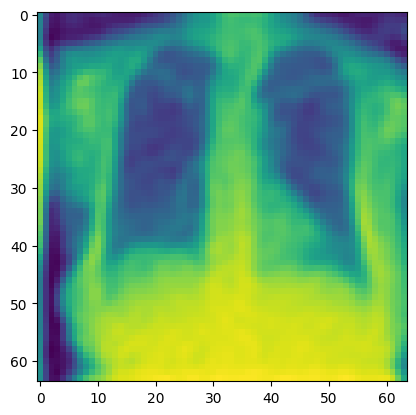

Step 900, Total loss 0.001530


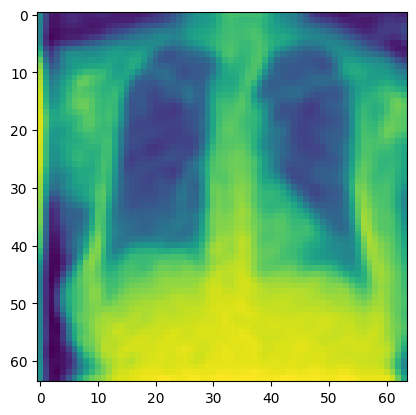

Step 1000, Total loss 0.001424


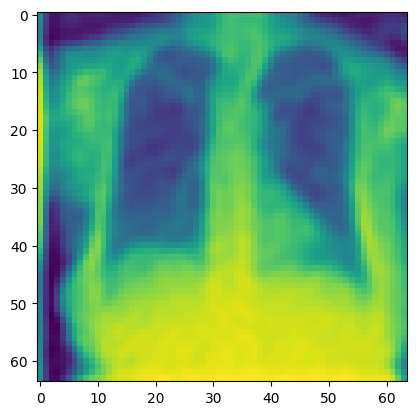

In [12]:
total_steps = 1001
steps_til_summary = 100

img_siren = Siren(in_features=2, out_features=1, hidden_features=resolution, 
                  hidden_layers=1, outermost_linear=True)
img_siren.cpu()

optim = torch.optim.SGD(lr=1e-2, params=img_siren.parameters())

model_input, ground_truth = next(iter(dataloader))
model_input, ground_truth = model_input.cpu(), ground_truth.cpu()

plt.imshow(ground_truth.view(resolution, resolution).detach().numpy())
plt.show()

for step in range(total_steps):
    model_output, coords = img_siren(model_input)
    loss = ((model_output - ground_truth)**2).mean()
    
    if not step % steps_til_summary:
        print("Step %d, Total loss %0.6f" % (step, loss))
        plt.imshow(model_output.cpu().view(resolution, resolution).detach().numpy())
        plt.show()

    optim.zero_grad()
    loss.backward()
    optim.step()

In [57]:
img_siren.cpu()

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=2, out_features=64, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=64, out_features=64, bias=True)
    )
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
# Auxiliary utility function to load different datasets (for plaintext analysis)

def load_data(resolution, dataset_names):
    import torch
    import skimage
    
    from PIL import Image
    from torchvision.transforms import Resize, Compose, ToTensor, Normalize
    from torch.utils.data import DataLoader, Dataset

    def get_mgrid(sidelen, dim):
        tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
        mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
        mgrid = mgrid.reshape(-1, dim)
        return mgrid

    def get_img_tensor(sidelength, name):
        if name == "cameraman":
            img = Image.fromarray(skimage.data.camera())        
            img = img.crop((192, 128, 320, 256))  # Crop to 128x128
        elif name == "chest":
            from medmnist import ChestMNIST
            dataset = ChestMNIST(split="train", download=True, size=64)
            img = Image.fromarray(dataset.imgs[0])
        elif name == "oct":
            from medmnist import OCTMNIST
            dataset = OCTMNIST(split="train", download=True, size=64)
            img = Image.fromarray(dataset.imgs[0])
        elif name == "organ":
            from medmnist import OrganAMNIST
            dataset = OrganAMNIST(split="train", download=True, size=64)
            img = Image.fromarray(dataset.imgs[0])
        else:
            raise ValueError(f"Non-supported image name: {name}")
        
        transform = Compose([
            Resize(sidelength),
            ToTensor(),
            Normalize(torch.Tensor([0.5]), torch.Tensor([0.5]))
        ])
        img = transform(img)

        return img

    class ImageFitting(Dataset):
        def __init__(self, sidelength, name):
            super().__init__()
            img = get_img_tensor(sidelength, name)
            self.pixels = img.permute(1, 2, 0).view(-1, 1)
            self.coords = get_mgrid(sidelength, 2)

        def __len__(self):
            return 1

        def __getitem__(self, idx):    
            if idx > 0: raise IndexError
            return self.coords, self.pixels
    
    data = {}
    for name in dataset_names:
        image_tensor = ImageFitting(resolution, name)
        dataloader = DataLoader(image_tensor, batch_size=1, pin_memory=True, num_workers=0)
        data[name] = next(iter(dataloader))

    return data

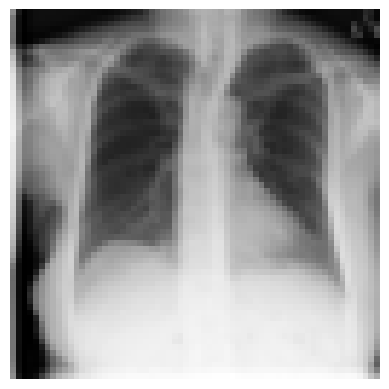

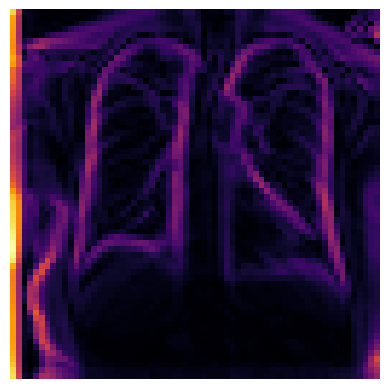

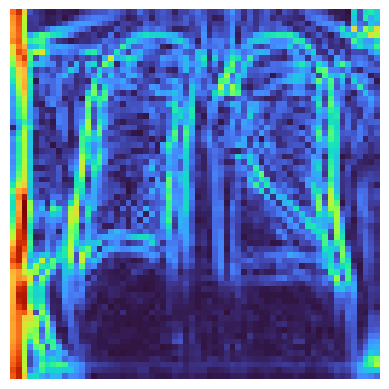

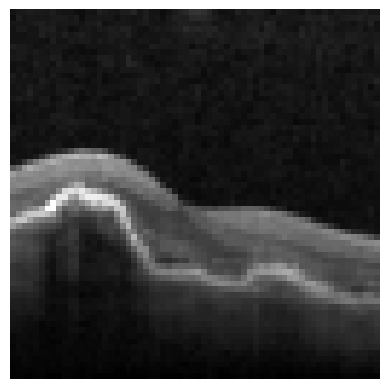

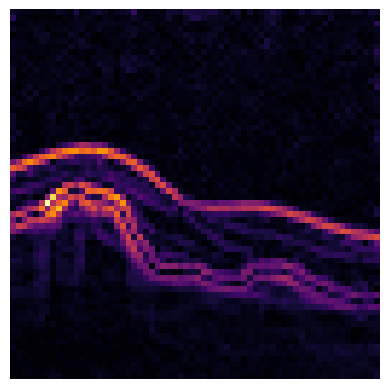

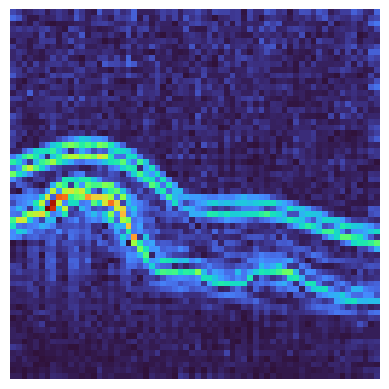

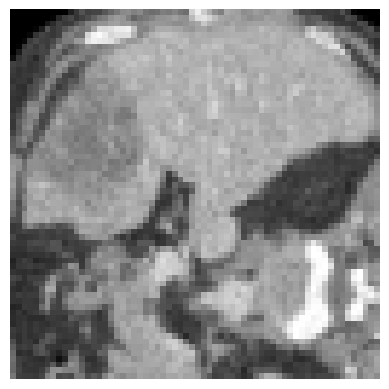

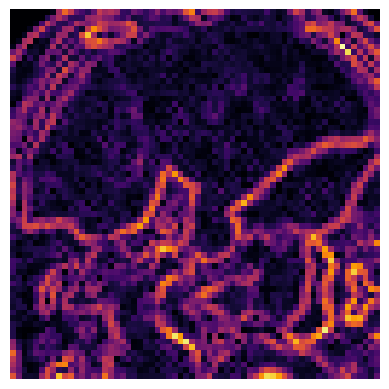

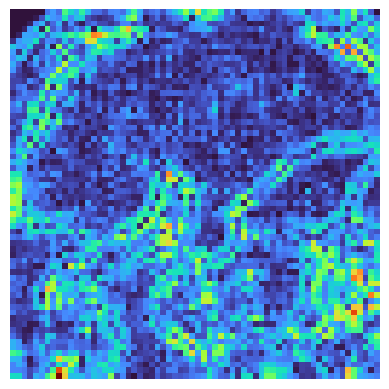

In [23]:
data = load_data(64, ["chest", "oct", "organ"])
coords = get_mgrid(64, 2)

for k, v in data.items():
    _, ground_truth = v
    img = ground_truth.view(64,64).detach().numpy()

    # Compute the gradient of img
    gx, gy = np.gradient(img)
    grad_img = np.hypot(gx, gy)

    # Compute the divergence of the gradient
    gxx, _ = np.gradient(gx)
    _, gyy = np.gradient(gy)
    div_img = np.hypot(gxx, gyy)

    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

    plt.imshow(grad_img, cmap='inferno')
    plt.axis('off')
    plt.show()

    plt.imshow(div_img, cmap='turbo')
    plt.axis('off')
    plt.show()